# Object Detection — Stage 1 (Localisation)

Trains `ObjectDetectorResNet` to predict up to `MAX_OBJECTS` bounding boxes per image.  
Each predicted slot is `[x, y, w, h, conf]`; confidence is a raw logit trained with BCE.

**Pipeline:**  
`get_detection_loaders` → `ObjectDetectorResNet` → `DetectionLoss` → `fit(task_type='detection')`

In [1]:
import sys
sys.path.insert(0, '..')

import torch

from utils.dataset   import get_detection_loaders, DetectionAugment
from utils.trainer   import fit
from utils.callbacks import ModelCheckpoint
from utils.losses    import DetectionLoss
from models import ObjectDetectorResNet

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 198
EPOCHS      = 60
MAX_OBJECTS = 24      # must match generator max_objects
CONF_THRESH = 0.5     # sigmoid threshold at inference
LAMBDA_CONF = 1.0     # weight on confidence loss

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.11.0+cu130


## 1 · Data Loaders

In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size = BATCH_SIZE,
    test=True,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
imgs, boxes, labels, mask = batch

print(f'Image batch shape : {imgs.shape}')
print(f'GT boxes shape    : {boxes.shape}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Image batch shape : torch.Size([198, 1, 224, 224])
GT boxes shape    : torch.Size([198, 19, 4])
Train batches: 1213 | Val batches: 76


## 2 · Model

In [3]:
model = ObjectDetectorResNet(max_objects=MAX_OBJECTS).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    out = model(imgs.to(DEVICE))
print(f'Output shape: {out.shape}')  # (B, MAX_OBJECTS, 5)  — [x, y, w, h, conf]

Parameters: 3,045,560
Output shape: torch.Size([198, 24, 5])


## 3 · Loss — Huber + BCE confidence

`DetectionLoss` lives in `utils/losses.py`:
- Greedy IoU match → each GT box assigned to the best predicted slot
- **Box loss**: `HuberLoss` on matched pairs
- **Conf loss**: `BCEWithLogitsLoss` — matched slots → 1.0, background → 0.0

In [4]:
criterion = DetectionLoss(lambda_conf=LAMBDA_CONF, delta=1.0)
print('DetectionLoss ready.')

# ── Quick loss smoke-test ─────────────────────────────────────────────────────
boxes_v = boxes.to(DEVICE)
mask_v = mask.to(DEVICE)

with torch.no_grad():
    dummy_out   = model(imgs.to(DEVICE))
    loss_val    = criterion(dummy_out, boxes_v, mask_v)
print(f'Smoke-test loss: {loss_val.item():.4f}')  # should be finite

DetectionLoss ready.
Smoke-test loss: 60.0982


## 4 · Optimiser & Scheduler

In [5]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
)

NAME = "detector_s_1"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
    mode='max'   # maximise val_iou
)

scaler = torch.amp.GradScaler('cuda')

print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')

Optimizer : AdamW
Scheduler : OneCycleLR


## 5 · Train

In [6]:
history = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    task_type   = 'detection',
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume=True
)

Training with bf16 autocast | Task: detection | Epochs: 60
[RunLogger] ▶  Run 'detector_s_1_20260714_082800' started — saving to 'C:\OD-From-Scratch\logs\ObjectDetectorResNet\detector_s_1_20260714_082800.json'
Resuming training from epoch 41
Batch  1 | match=1.00 data=665.9ms pad=0.9ms forward=212.8ms loss=8.2ms backward=273.6ms step=154.5ms
Batch  2 | match=1.00 data=0.3ms pad=0.9ms forward=15.4ms loss=4.3ms backward=35.8ms step=2.7ms
Batch  3 | match=1.00 data=0.2ms pad=0.8ms forward=15.3ms loss=4.0ms backward=31.3ms step=2.4ms
Batch  4 | match=1.00 data=0.1ms pad=0.8ms forward=15.2ms loss=3.8ms backward=32.0ms step=2.8ms
Batch  5 | match=1.00 data=0.2ms pad=0.8ms forward=15.2ms loss=5.5ms backward=31.5ms step=2.6ms
  --> Epoch Average Match Ratio: 1.0000
Validation batches: 76
Train: 70.0s | Val: 43.9s
[RunLogger] Epoch  42 | train_loss=0.6508  val_loss=0.6544  val_iou=0.8903  lr=3.89e-04  ⏱ 70.0s  ★ NEW BEST
Batch  1 | match=1.00 data=538.1ms pad=0.9ms forward=17.8ms loss=6.3ms bac

## 6 · Training Curves

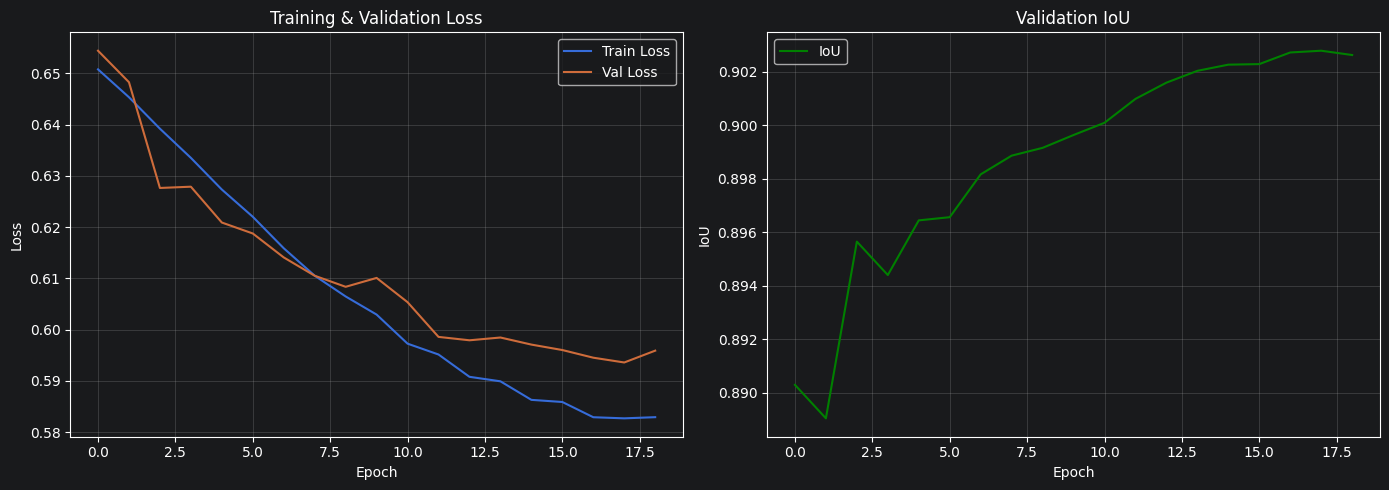

In [7]:
from utils.visualizer import Visualizer

Visualizer.visualize_training_curves(history['train_loss'], history['val_loss'], history['val_iou'], metric_label='IoU')

## 7 · Prediction Visualisation

- **Green** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH`

In [8]:
# ── Evaluate on Test Set ──────────────────────────────────────────────────────
from utils.trainer import evaluate_detection
checkpoint.restore_best_weights()
test_loss, test_iou = evaluate_detection(model, test_loader, criterion, DEVICE)
print(f"Test loss: {test_loss:.3f}, Test IoU: {test_iou:.3f}")

Validation batches: 228
Test loss: 0.595, Test IoU: 0.903


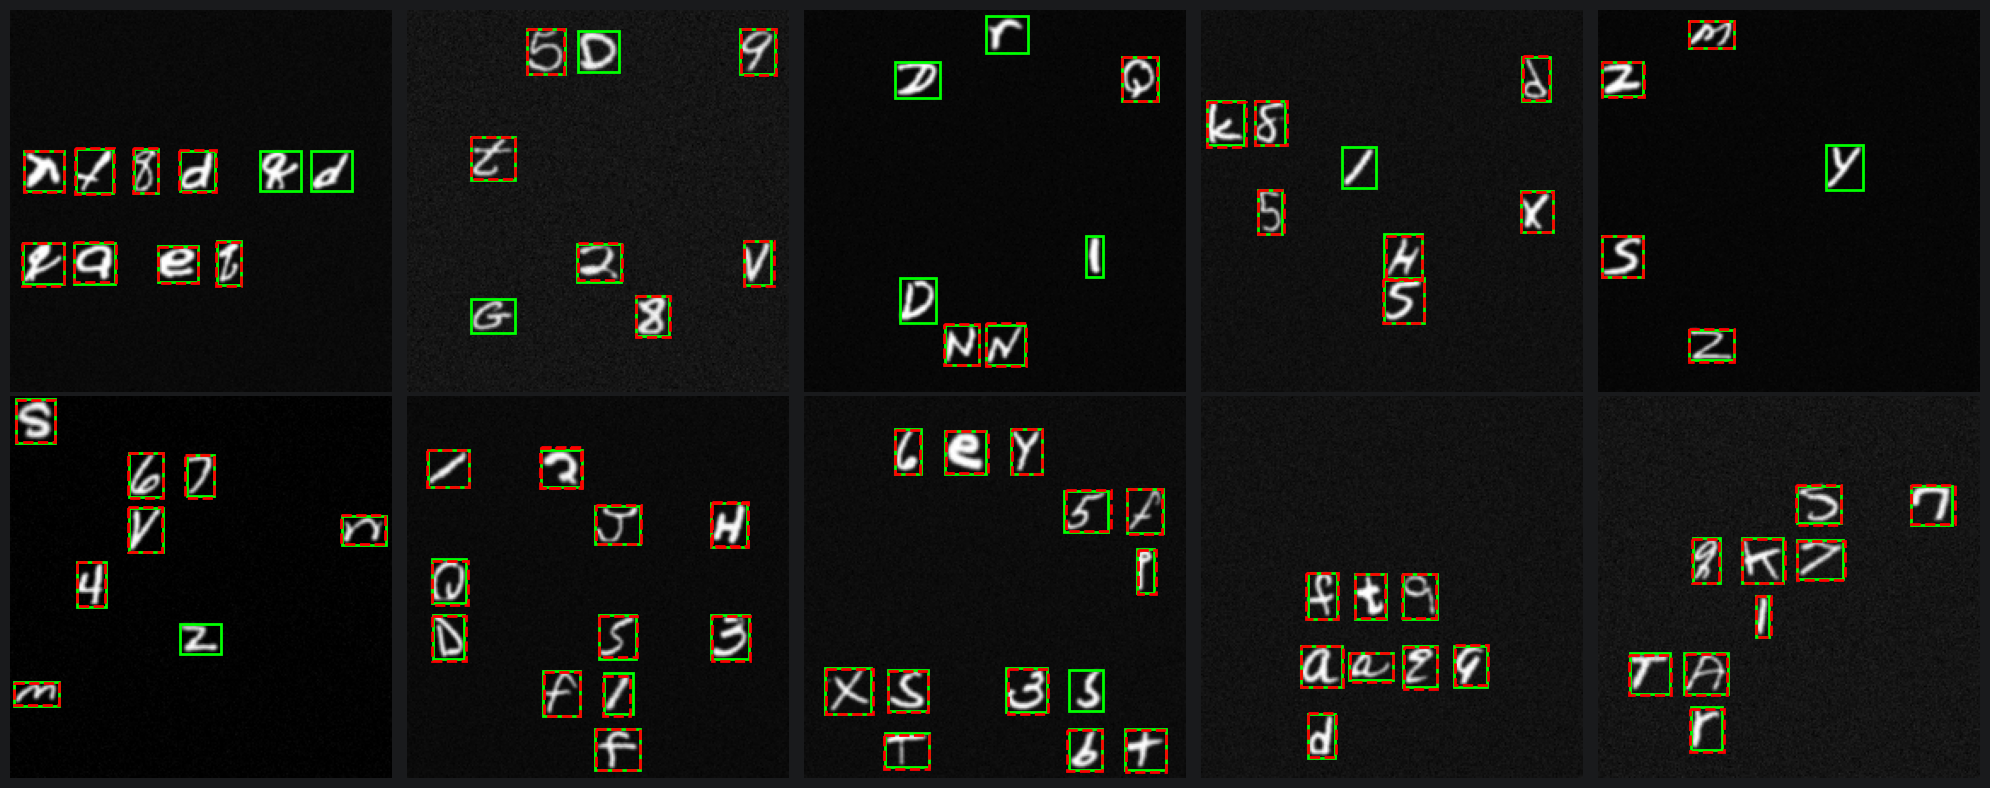

In [9]:
test_batch = next(iter(test_loader))
imgs_t, boxes_t, labels_t, mask_t = test_batch
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE)).cpu()
Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=preds_t,
    boxes_v=boxes_t,
    mask_v=mask_t,
    conf_thresh=CONF_THRESH
)

In [10]:
print(train_loader.sampler)
print(val_loader.sampler)
print(test_loader.sampler)